# Lab 5: Model Development — PlantCLEF Provider Classification
| | |
|---|---|
| **วิชา** | 01076251 Machine Learning for Data Science |
| **กลุ่ม** | ปิยังกูร ปัสสาวะกัง (6810405691) และ ศิวภูมิ พรหมจรรย์ (6810405887) |



In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.pipeline import make_pipeline as make_imblearn_pipeline
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42

## 1. ประเภทปัญหา

### 1.1 ประเภทปัญหา ML
**Multiclass Classification** (การจำแนกประเภทหลายคลาส)

* **เหตุผล:** โจทย์เป็นการทำนายแหล่งที่มาของภาพถ่ายพืช (`provider`) ซึ่งเป็นข้อมูลเชิงกลุ่ม (Categorical Data)
* **คลาสเป้าหมาย:** มีทั้งหมด 5 คลาส ได้แก่ `CBN`, `LISAH`, `GUARDEN`, `RNNB`, และ `OPTMix`

### 1.2 Algorithm ที่เลือกใช้และเหตุผล

* **Logistic Regression:** ใช้ `Baseline Model` มีความเร็วในการประมวลผลสูง เหมาะสำหรับ `Feature Embeddings` ที่มีมิติสูง (384 มิติ) และตีความความน่าจะเป็นของแต่ละคลาสได้ง่าย
* **Random Forest Classifier:** เป็น `Tree-based Model` ที่จับความสัมพันธ์แบบไม่เป็นเชิงเส้น ระหว่างคุณลักษณะภาพได้ดี ทนทานต่อ `Noise` และช่วยลดปัญหา `Overfitting`
* **Voting Classifier (Ensemble):** รวมผลการทำนายจากหลายอัลกอริทึม `(Logistic Regression, Ridge Classifier, Random Forest)` เข้าด้วยกัน เพื่อเพิ่มความเสถียรและค่าความแม่นยำ (Accuracy) ให้กับโมเดล

### 1.3 Hyperparameters หลักและช่วงค่าที่ทดลองปรับ

**Logistic Regression**
* **C (Inverse Regularization Strength):** `[0.01, 0.1, 1.0, 10.0]`
* **solver:** `['lbfgs', 'saga']`

**Random Forest Classifier**
* **n_estimators (จำนวนต้นไม้):** `[100, 200, 300]`
* **max_depth (ความลึกสูงสุดของต้นไม้):** `[10, 20, None]`
* **min_samples_split (จำนวนตัวอย่างขั้นต่ำในการแยกโหนด):** `[2, 5, 10]`

In [11]:
# 1. โหลด DINOv2 Features จาก แลป 4 
X_train = np.load('./X_train_dinov2.npy')
X_val = np.load('./X_val_dinov2.npy')

# 2. โหลด Metadata และดึง Label 'provider'
i_train = pd.read_parquet('./i_train.parquet')
i_val = pd.read_parquet('./i_val.parquet')

y_train_raw = i_train['provider']
y_val_raw = i_val['provider']

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)

print("Data Shape")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print("\nClass Mapping:", dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_)))

Data Shape
X_train: (1472, 384) | y_train: (1472,)
X_val:   (316, 384) | y_val:   (316,)

Class Mapping: {0: 'CBN', 1: 'GUARDEN', 2: 'LISAH', 3: 'OPTMix', 4: 'RNNB'}


In [12]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

train_acc = baseline_model.score(X_train, y_train)
val_acc = baseline_model.score(X_val, y_val)

print("Baseline Model")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy:   {val_acc:.4f}")

Baseline Model
Train Accuracy: 1.0000
Val Accuracy:   0.9778


In [13]:
os_pipeline = make_imblearn_pipeline(
    RandomOverSampler(random_state=RANDOM_STATE),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

os_pipeline.fit(X_train, y_train)
y_pred_os = os_pipeline.predict(X_val)

print("OverSampled Logistic Regression Performance")
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_os):.4f}\n")
print(classification_report(y_val, y_pred_os, target_names=label_encoder.classes_))

OverSampled Logistic Regression Performance
Validation Accuracy: 0.9715

              precision    recall  f1-score   support

         CBN       1.00      1.00      1.00       221
     GUARDEN       0.87      0.90      0.89        30
       LISAH       0.97      0.88      0.92        32
      OPTMix       0.92      0.92      0.92        12
        RNNB       0.87      0.95      0.91        21

    accuracy                           0.97       316
   macro avg       0.92      0.93      0.93       316
weighted avg       0.97      0.97      0.97       316



In [14]:
# กำหนด Grid ในการค้นหาค่า Hyperparameter ที่เหมาะสมที่สุด
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(rf_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Hyperparameter Tuning (Random Forest)")
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Score:    {grid_search.best_score_:.4f}")
print(f"Val Accuracy:     {best_rf.score(X_val, y_val):.4f}")

Hyperparameter Tuning (Random Forest)
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score:    0.9368
Val Accuracy:     0.9335


## 2. การแบ่งข้อมูล Train/Val/Test และ Post-process ผลลัพธ์

### 2.1 การแบ่งข้อมูล (Data Splitting)
* **สัดส่วน:** แบ่งออกเป็น Train Set จำนวน 1,472 ตัวอย่าง และ Validation Set จำนวน 316 ตัวอย่าง (คิดเป็นอัตราส่วนประมาณ 82:18) ตามโครงสร้างชุดข้อมูล `X_train_dinov2.npy` และ `X_val_dinov2.npy`
* **เหตุผล:** สัดส่วนนี้ช่วยให้โมเดลมีข้อมูลเพียงพอ เรียนรู้โครงสร้าง Feature ของภาพพืช ในขณะที่แบ่งสัดส่วน Validation ไว้ 18% เพื่อใช้วัดประสิทธิภาพ ป้องกัน Overfitting และประเมินความสามารถในการปรับตัวกับข้อมูลใหม่

### 2.2 การ Post-process ผลลัพธ์
* **Class Imbalance Handling:** ใช้ `RandomOverSampler` สุ่มเพิ่มจำนวนข้อมูลในคลาสที่มีน้อย เพื่อไม่ให้โมเดลทำนายเอนเอียงไปยังคลาสที่มีจำนวนข้อมูลมาก (เช่น `CBN`)
* **Inverse Label Encoding:** แปลงผลการทำนายที่เป็นตัวเลขเชิงดรรชนี ($0, 1, 2, 3, 4$) กลับมาเป็นชื่อสตริงขององค์กรผู้ให้บริการ (`provider`) เช่น `CBN`, `LISAH`, `GUARDEN` เพื่อให้ผู้ใช้งานนำไปประมวลผลต่อได้ทันที
* **Confidence Thresholding (แล้วแต่จำเป็น):** หากนำไปใช้ในระบบ Production สามารถกำหนด threshold ความน่าจะเป็นขั้นต่ำ หากความน่าจะเป็นสูงสุดต่ำกว่าเกณฑ์ ให้ตีความว่าเป็น "Unknown Provider" เพื่อป้องกันการทำนายผิดพลาด

Final Ensemble Model
Final Validation Accuracy: 0.9810



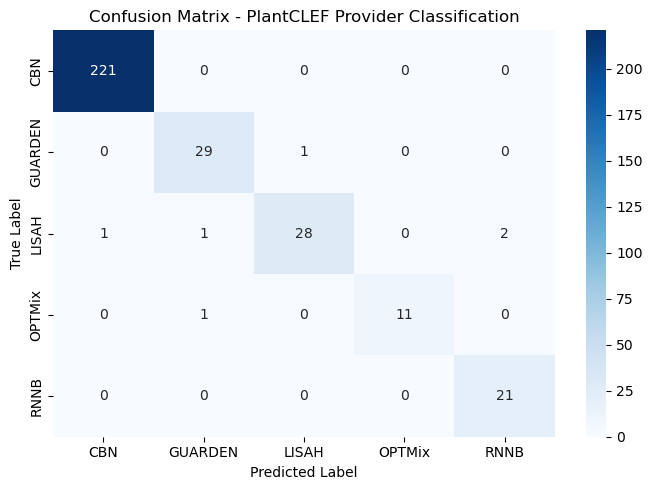

In [15]:
# สร้าง Voting Classifier เพื่อรวมประสิทธิภาพโมเดล
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
        ('ridge', RidgeClassifier(alpha=1.0, random_state=RANDOM_STATE)),
        ('rf', best_rf)
    ],
    voting='hard'
)

ensemble_model.fit(X_train, y_train)
y_pred_final = ensemble_model.predict(X_val)

print("Final Ensemble Model")
print(f"Final Validation Accuracy: {accuracy_score(y_val, y_pred_final):.4f}\n")

cm = confusion_matrix(y_val, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - PlantCLEF Provider Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [16]:
model_artifacts = {
    'model': ensemble_model,
    'label_encoder': label_encoder
}
joblib.dump(model_artifacts, 'plantclef_provider_model.joblib')
print("Model artifacts successfully saved to 'plantclef_provider_model.joblib'")

# ทดสอบระบบทำนายผล และ Post-Processing
loaded_artifacts = joblib.load('plantclef_provider_model.joblib')
model = loaded_artifacts['model']
encoder = loaded_artifacts['label_encoder']

# ทดลองทำนาย 5 ข้อมูลแรก
raw_predictions = model.predict(X_val[:5])
final_labels = encoder.inverse_transform(raw_predictions)
actual_labels = encoder.inverse_transform(y_val[:5])

print("\nPost-Processing Prediction Output")
for i in range(5):
    print(f"Sample {i+1} | Actual: {actual_labels[i]:<10} | Predicted: {final_labels[i]}")

Model artifacts successfully saved to 'plantclef_provider_model.joblib'

Post-Processing Prediction Output
Sample 1 | Actual: CBN        | Predicted: CBN
Sample 2 | Actual: LISAH      | Predicted: LISAH
Sample 3 | Actual: CBN        | Predicted: CBN
Sample 4 | Actual: GUARDEN    | Predicted: GUARDEN
Sample 5 | Actual: LISAH      | Predicted: LISAH


---
## ส่วนท้าย: สรุปผลและการมีส่วนร่วมของสมาชิก

### สรุปสิ่งที่ได้จากงานนี้
1. **การเข้าใจโครงสร้างปัญหา ML**: ได้กำหนดโจทย์การทำนายแหล่งที่มาของภาพ เป็นปัญหา Multiclass Classification 5 คลาส แบบถูกต้อง
2. **การจัดการข้อมูลมิติสูง**: รู้การนำ Feature Embeddings ขนาด 384 มิติจาก DINOv2 มาใช้ฝึกโมเดลจำแนกประเภทภาพถ่าย
3. **การแก้ปัญหาข้อมูลไม่สมดุล (Class Imbalance)**: ได้ประยุกต์ใช้ RandomOverSampler ใน Pipeline เพื่อลดความเอนเอียงของโมเดลไปยังคลาสที่มีปริมาณข้อมูลมาก
4. **การเปรียบเทียบและปรับแต่งโมเดล**: ได้ทดลองใช้โมเดลที่หลากหลายตั้งแต่ Baseline ไปจนถึง Random Forest พร้อมหาค่า Hyperparameter ที่ดีที่สุดด้วย GridSearchCV
5. **การเพิ่มประสิทธิภาพด้วย Ensemble Learning**: ได้รวมความแม่นยำของหลายอัลกอริทึมด้วย VotingClassifier ทำให้โมเดลเสถียรยิ่งขึ้น

### การมีส่วนร่วมของสมาชิก
| ชื่อ | รหัส | หน้าที่รับผิดชอบ |
|---|---|---|
| ปิยังกูร ปัสสาวะกัง | 6810405691 | หาปัญหาของ ml แล้วช่วยคิดว่าจะแก้ปัญหายังไงดี |
| ศิวภูมิ พรหมจรรย์ | 6810405887 | สร้าง Baseline Model จัดการปัญหา Class Imbalance เขียนโค้ด เขียนรายงาน|

### การเปิดเผยการใช้งานปัญญาประดิษฐ์

ในแบบฝึกหัดนี้ กลุ่มของพวกผมมีการใช้ผู้ช่วยปัญญาประดิษฐ์ในการดำเนินงานดังต่อไปนี้
1. ช่วยตรวจสอบความถูกต้องของ ML ที่เทรนต่างๆว่าที่ทำมาถูกรึป่าว 
2. ช่วยตอบคำถามต่างๆว่าควรทำยังไง กับปัญหาที่เจอ
